<a href="https://colab.research.google.com/github/santhoshvarma0007/project/blob/main/heart%20attack_full_code__update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CELL 1: Import required libraries
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [ ]:
# ============================================
# CELL 2: Load dataset
# ============================================

# Replace the file path if your CSV is in a different location
df = pd.read_csv("Medicaldataset.csv")

# Display first 5 rows
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
# ============================================
# CELL 3: Basic dataset inspection
# ============================================

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (1319, 9)

Column names:
['Age', 'Gender', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin', 'Result']

Data types:
Age                           int64
Gender                        int64
Heart rate                    int64
Systolic blood pressure       int64
Diastolic blood pressure      int64
Blood sugar                 float64
CK-MB                       float64
Troponin                    float64
Result                       object
dtype: object

Missing values:
Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

Duplicate rows: 0


In [ ]:
# ============================================
# CELL 4: Rename columns for easier handling
# ============================================

df = df.rename(columns={
    "Heart rate": "Heart_rate",
    "Systolic blood pressure": "Systolic_BP",
    "Diastolic blood pressure": "Diastolic_BP",
    "Blood sugar": "Blood_sugar",
    "CK-MB": "CK_MB"
})

print(df.columns.tolist())

['Age', 'Gender', 'Heart_rate', 'Systolic_BP', 'Diastolic_BP', 'Blood_sugar', 'CK_MB', 'Troponin', 'Result']


In [ ]:
# ============================================
# CELL 5: Check target classes
# ============================================

print(df["Result"].value_counts())
print("\nTarget distribution (%):")
print(df["Result"].value_counts(normalize=True) * 100)

Result
positive    810
negative    509
Name: count, dtype: int64

Target distribution (%):
Result
positive    61.410159
negative    38.589841
Name: proportion, dtype: float64


In [ ]:
# ============================================
# CELL 6: Encode target variable
# ============================================

df["Result"] = df["Result"].map({
    "negative": 0,
    "positive": 1
})

print(df["Result"].value_counts())
df.head()

Result
1    810
0    509
Name: count, dtype: int64


,Age,Gender,Heart_rate,Systolic_BP,Diastolic_BP,Blood_sugar,CK_MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0


In [ ]:
# ============================================
# CELL 7: Remove outliers using IQR method
# ============================================

# Numerical columns for outlier treatment
num_cols = ["Age", "Heart_rate", "Systolic_BP", "Diastolic_BP", "Blood_sugar", "CK_MB", "Troponin"]

# Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Reset index after removing rows
df = df.reset_index(drop=True)

print("Shape after outlier removal:", df.shape)
df.head()

Shape after outlier removal: (788, 9)


,Age,Gender,Heart_rate,Systolic_BP,Diastolic_BP,Blood_sugar,CK_MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,55,1,64,160,77,270.0,1.99,0.003,0
2,58,0,61,112,58,87.0,1.83,0.004,0
3,32,0,40,179,68,102.0,0.71,0.003,0
4,44,0,60,154,81,135.0,2.35,0.004,0


In [ ]:
# ============================================
# CELL 8: Import visualization libraries
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
# ============================================
# CELL 9: Basic overview
# ============================================

print("Shape of dataset:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe())

Shape of dataset: (788, 9)

Data types:
Age               int64
Gender            int64
Heart_rate        int64
Systolic_BP       int64
Diastolic_BP      int64
Blood_sugar     float64
CK_MB           float64
Troponin        float64
Result            int64
dtype: object

Summary statistics:


,Age,Gender,Heart_rate,Systolic_BP,Diastolic_BP,Blood_sugar,CK_MB,Troponin,Result
count,788.000000,788.000000,788.000000,788.000000,788.000000,788.000000,788.000000,788.000000,788.000000
mean,55.605330,0.624365,74.993655,125.647208,71.842640,130.233122,3.114599,0.022079,0.434010
std,13.731324,0.484594,13.865710,23.504843,13.376404,48.120653,2.151614,0.032481,0.495941
min,21.000000,0.000000,36.000000,65.000000,38.000000,35.000000,0.321000,0.002000,0.000000
25%,45.000000,0.000000,63.000000,110.000000,61.000000,96.000000,1.600000,0.005000,0.000000
50%,56.000000,1.000000,74.000000,124.000000,71.000000,111.000000,2.490000,0.010000,0.000000
75%,66.000000,1.000000,84.000000,142.250000,81.000000,152.000000,4.077500,0.023000,1.000000
max,91.000000,1.000000,116.000000,193.000000,105.000000,279.000000,11.940000,0.192000,1.000000


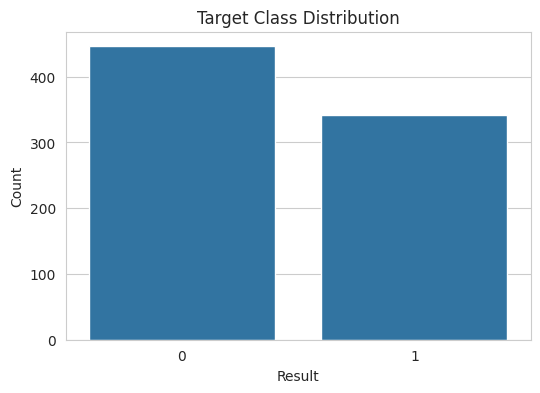

Result
0    446
1    342
Name: count, dtype: int64

Percentage distribution:
Result
0    56.598985
1    43.401015
Name: proportion, dtype: float64


In [ ]:
# ============================================
# CELL 10: Target class distribution
# ============================================

plt.figure(figsize=(6, 4))
sns.countplot(x="Result", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

print(df["Result"].value_counts())
print("\nPercentage distribution:")
print(df["Result"].value_counts(normalize=True) * 100)

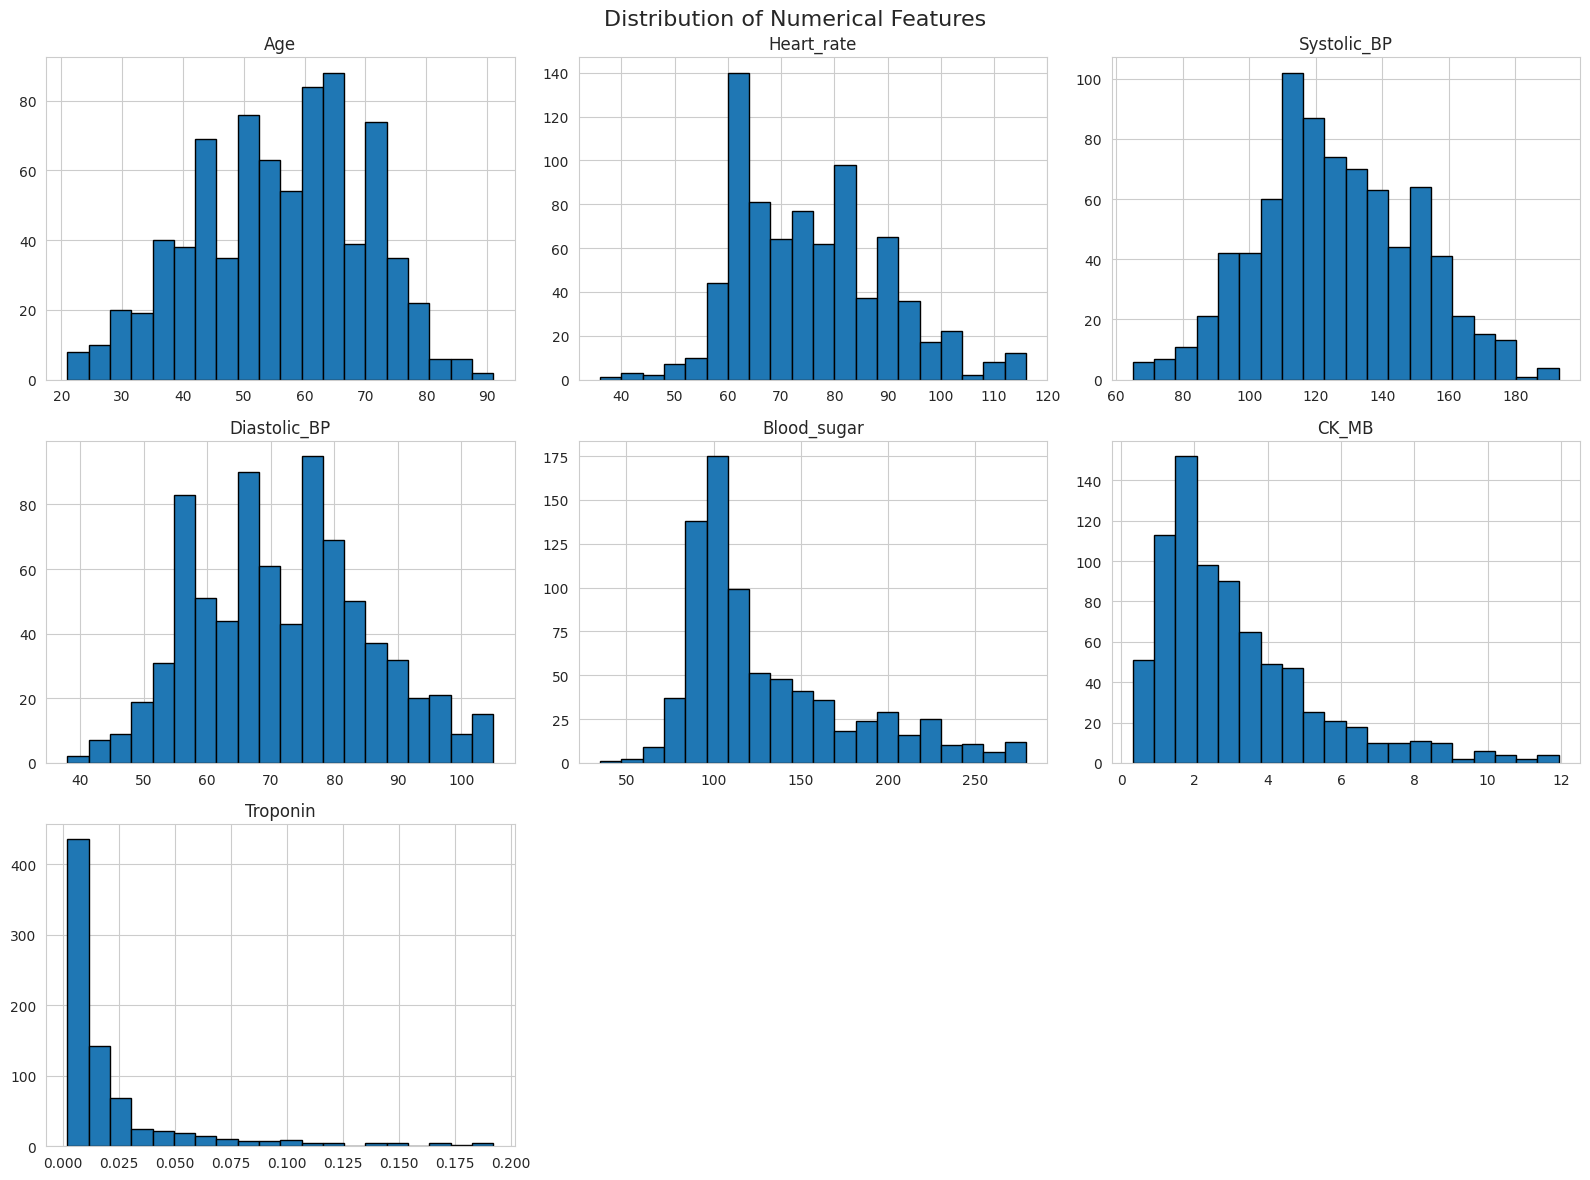

In [ ]:
# ============================================
# CELL 11: Histograms of numerical features
# ============================================

num_cols = ["Age", "Heart_rate", "Systolic_BP", "Diastolic_BP", "Blood_sugar", "CK_MB", "Troponin"]

df[num_cols].hist(bins=20, figsize=(16, 12), edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

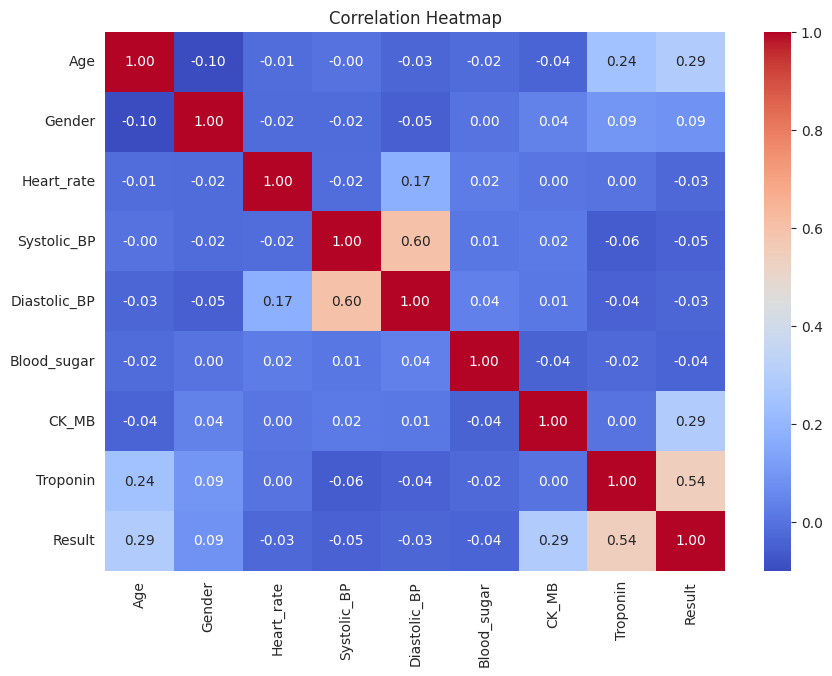

In [ ]:
# ============================================
# CELL 13: Correlation heatmap
# ============================================

plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

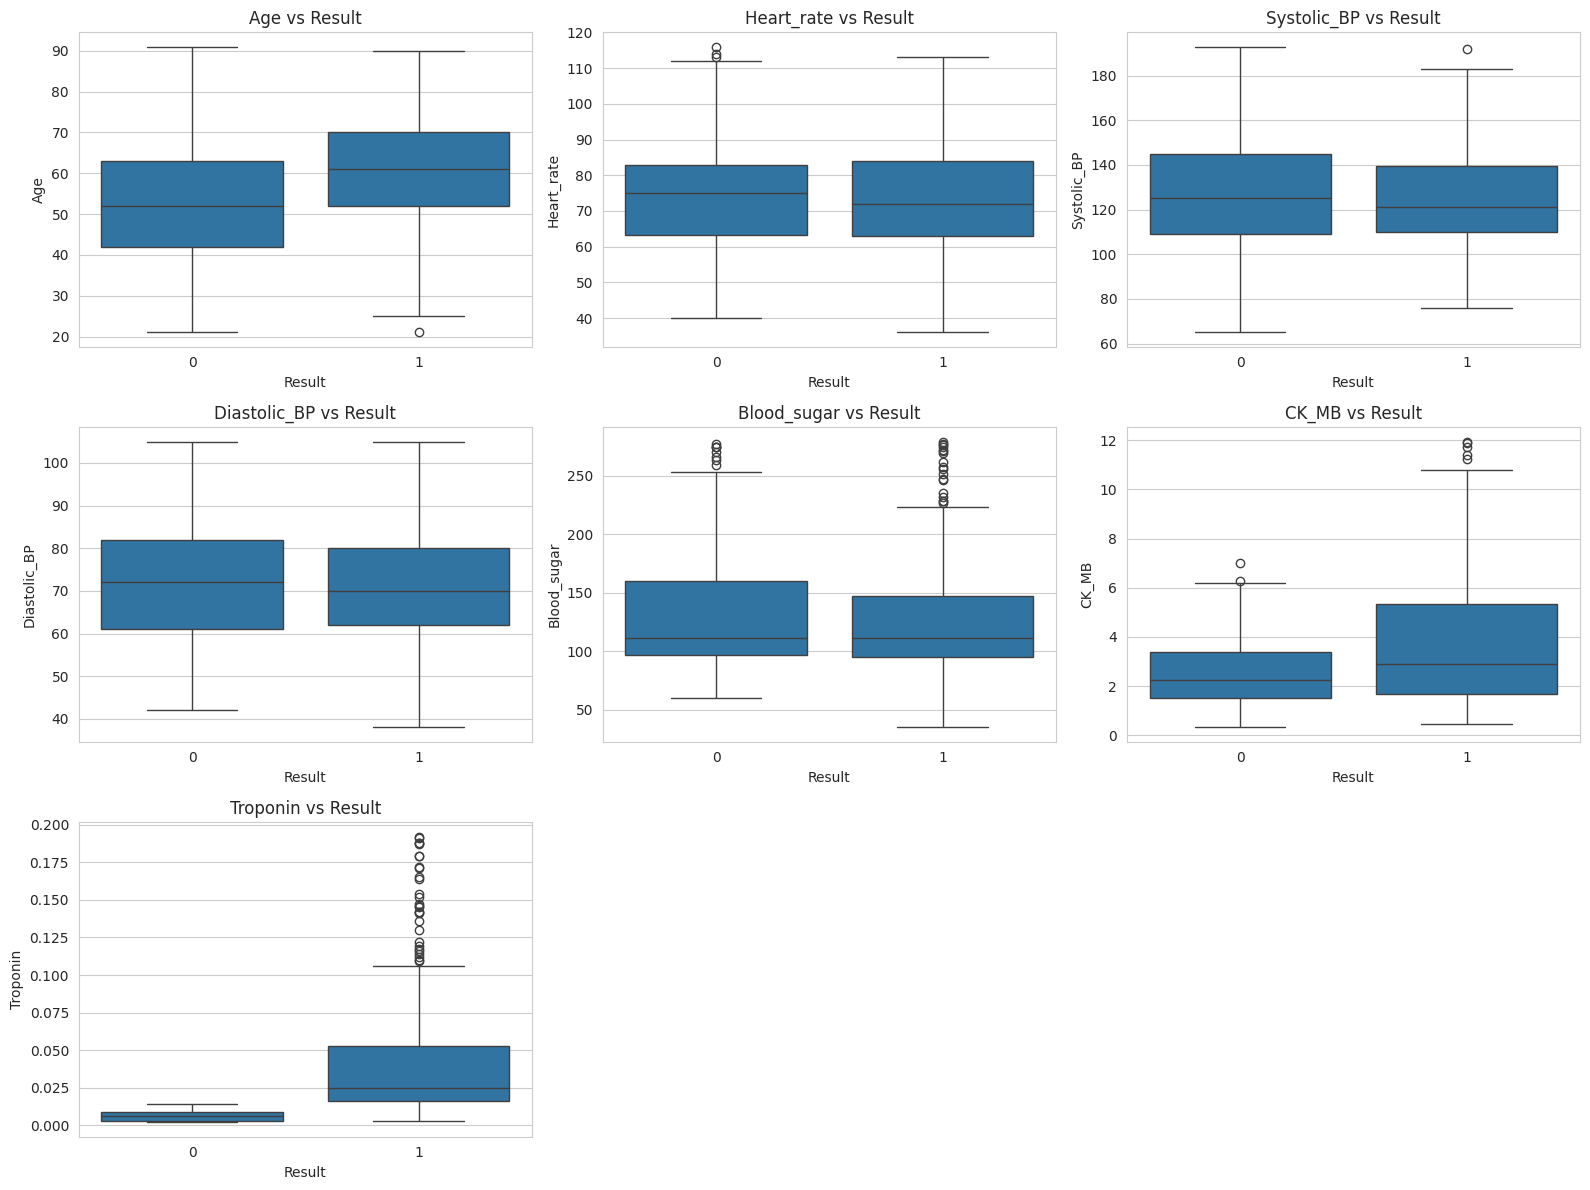

In [ ]:
# ============================================
# CELL 14: Boxplots of features by target class
# ============================================

plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x="Result", y=col, data=df)
    plt.title(f"{col} vs Result")

plt.tight_layout()
plt.show()

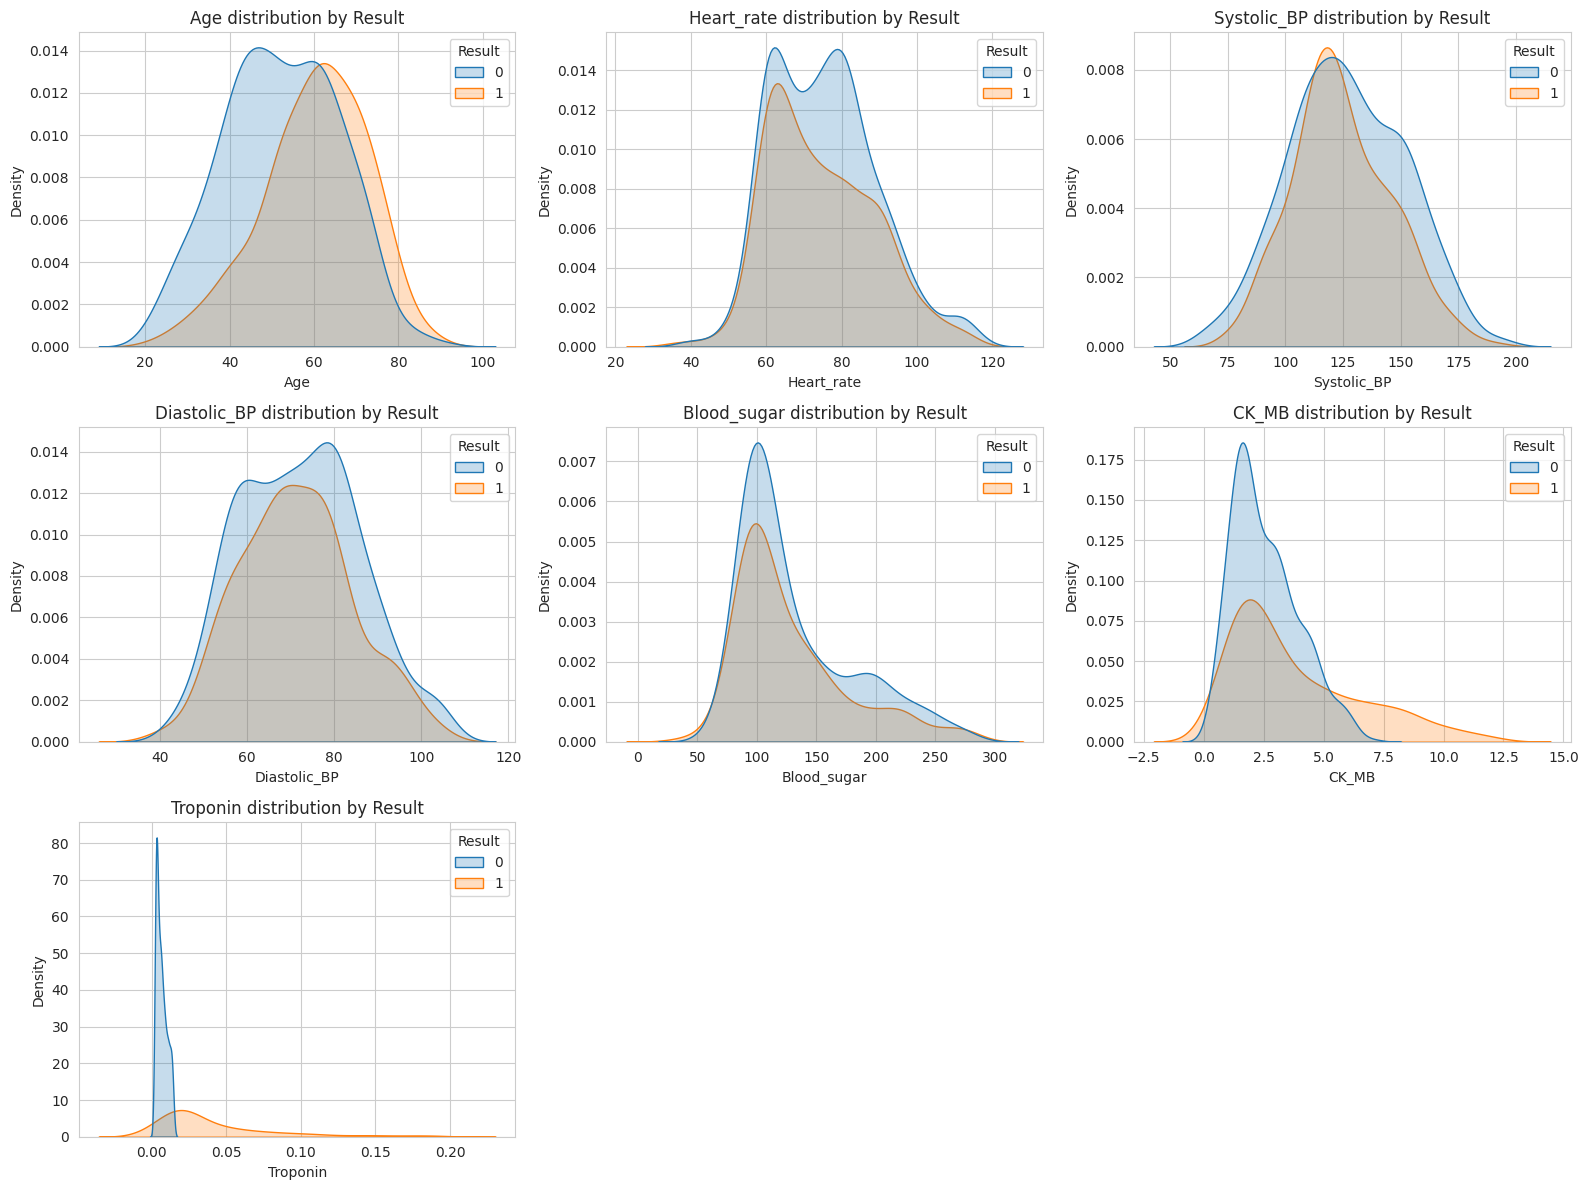

In [ ]:
# ============================================
# CELL 20: KDE plots by target class
# ============================================

plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=col, hue="Result", fill=True)
    plt.title(f"{col} distribution by Result")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL : Define features and target
# ============================================

X = df.drop("Result", axis=1)
y = df["Result"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget values:")
print(y.unique())

X shape: (788, 8)
y shape: (788,)

Target values:
[0 1]


In [ ]:
# ============================================
# CELL 23: Train-test split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (630, 8)
X_test shape : (158, 8)
y_train shape: (630,)
y_test shape : (158,)


In [ ]:
# ============================================
# CELL 24: Standard scaling
# ============================================

from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling completed.")
display(X_train_scaled.head())

Scaling completed.


,Age,Gender,Heart_rate,Systolic_BP,Diastolic_BP,Blood_sugar,CK_MB,Troponin
460,0.971783,-1.283378,-0.147746,0.397462,0.683558,-1.281475,0.817478,-0.459612
683,-0.920490,0.779194,1.085583,-0.072735,2.087985,-0.436119,3.014739,-0.491168
589,-0.411032,-1.283378,0.432644,-0.072735,0.240055,-0.353646,-1.319313,-0.585835
304,-0.265473,0.779194,1.811071,-0.286460,-0.425200,-0.085606,3.947190,-0.112499
176,-0.192693,0.779194,-1.090880,-0.542931,-1.460041,0.203052,1.851483,-0.301833


In [ ]:
# ============================================
#  Import machine learning models
# and evaluation metrics
# ============================================

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Plotting library
import matplotlib.pyplot as plt

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        89
           1       0.96      1.00      0.98        69

    accuracy                           0.98       158
   macro avg       0.98      0.98      0.98       158
weighted avg       0.98      0.98      0.98       158

Random Forest ROC-AUC Score: 0.999267220322423


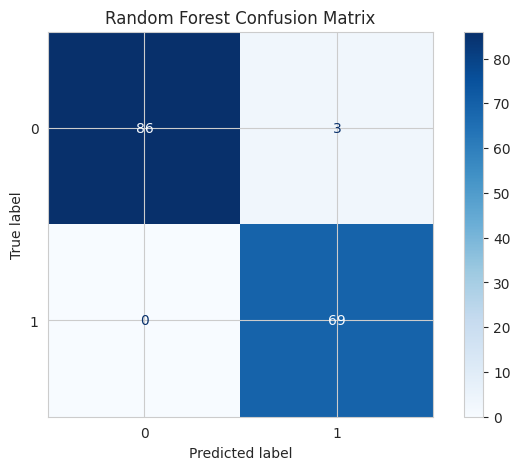

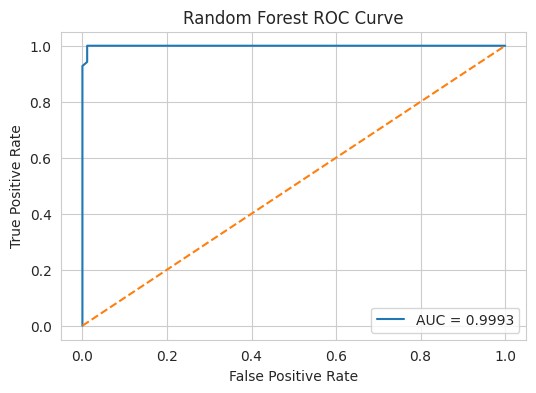

In [ ]:
# ============================================
# CELL 26: Train and evaluate Random Forest
# ============================================

# Create the Random Forest model
# n_estimators = number of trees in the forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model on unscaled training data
rf_model.fit(X_train, y_train)

# Predict class labels on test data
y_pred_rf = rf_model.predict(X_test)

# Predict probabilities for the positive class
# Needed for ROC-AUC and ROC curve
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Print classification report
# Includes precision, recall, f1-score, support
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Print ROC-AUC score
rf_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC Score:", rf_auc)

# Create and display confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Compute ROC curve values
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {rf_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        89
           1       0.94      0.84      0.89        69

    accuracy                           0.91       158
   macro avg       0.91      0.90      0.90       158
weighted avg       0.91      0.91      0.90       158

SVM ROC-AUC Score: 0.9780166096726918


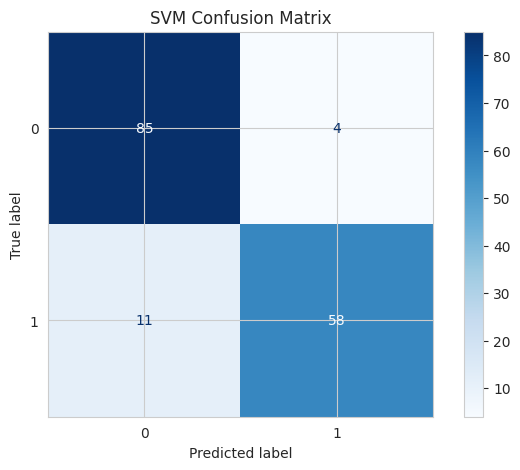

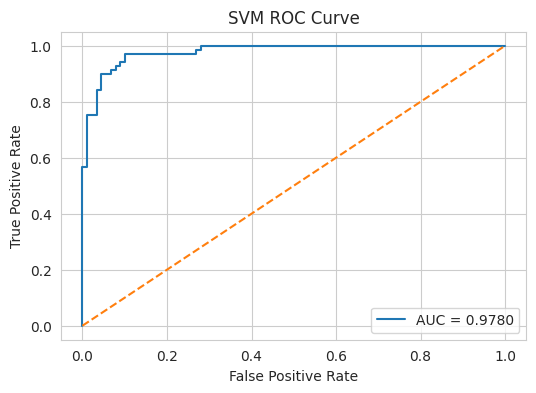

In [ ]:
# ============================================
# CELL 27: Train and evaluate SVM
# ============================================

# Create the SVM model
# kernel='rbf' is commonly used for non-linear classification
# probability=True is required to get probability scores
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Train the model on scaled training data
svm_model.fit(X_train_scaled, y_train)

# Predict class labels on scaled test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Predict probabilities for the positive class
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Print classification report
print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

# Print ROC-AUC score
svm_auc = roc_auc_score(y_test, y_prob_svm)
print("SVM ROC-AUC Score:", svm_auc)

# Create and display confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

# Compute ROC curve values
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr_svm, tpr_svm, label=f"AUC = {svm_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

ANN Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.91      0.94        89
           1       0.89      0.96      0.92        69

    accuracy                           0.93       158
   macro avg       0.93      0.93      0.93       158
weighted avg       0.93      0.93      0.93       158

ANN ROC-AUC Score: 0.9887640449438202


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


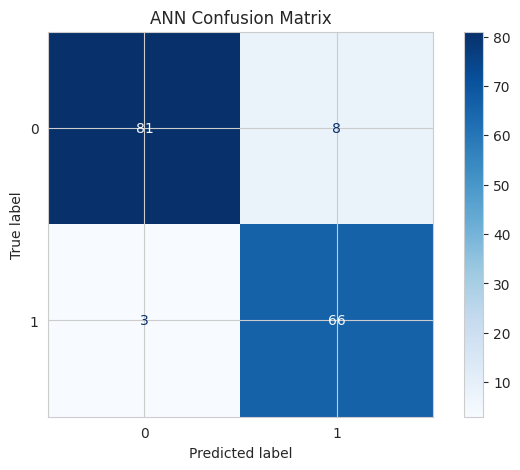

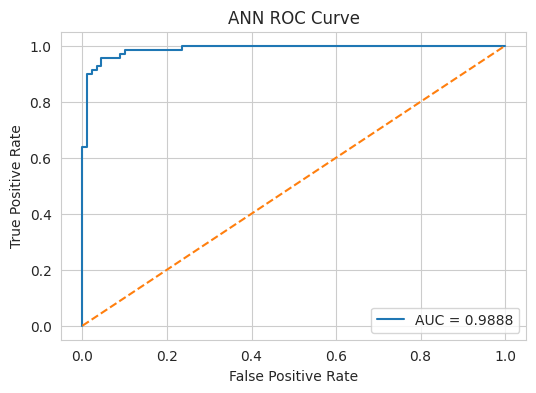

In [ ]:
# ============================================
# CELL 28: Train and evaluate ANN
# ============================================

# Create the Artificial Neural Network model
# hidden_layer_sizes=(64, 32) means:
# first hidden layer has 64 neurons
# second hidden layer has 32 neurons
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Train the ANN model on scaled training data
ann_model.fit(X_train_scaled, y_train)

# Predict class labels on scaled test data
y_pred_ann = ann_model.predict(X_test_scaled)

# Predict probabilities for the positive class
y_prob_ann = ann_model.predict_proba(X_test_scaled)[:, 1]

# Print classification report
print("ANN Classification Report:\n")
print(classification_report(y_test, y_pred_ann))

# Print ROC-AUC score
ann_auc = roc_auc_score(y_test, y_prob_ann)
print("ANN ROC-AUC Score:", ann_auc)

# Create and display confusion matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ann)
disp.plot(cmap="Blues")
plt.title("ANN Confusion Matrix")
plt.show()

# Compute ROC curve values
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr_ann, tpr_ann, label=f"AUC = {ann_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")
plt.legend()
plt.show()

In [ ]:
# ============================================
# CELL 29: Compare ROC-AUC scores
# ============================================

print("ROC-AUC Scores of all models:\n")
print("Random Forest AUC :", rf_auc)
print("SVM AUC           :", svm_auc)
print("ANN AUC           :", ann_auc)

ROC-AUC Scores of all models:

Random Forest AUC : 0.999267220322423
SVM AUC           : 0.9780166096726918
ANN AUC           : 0.9887640449438202


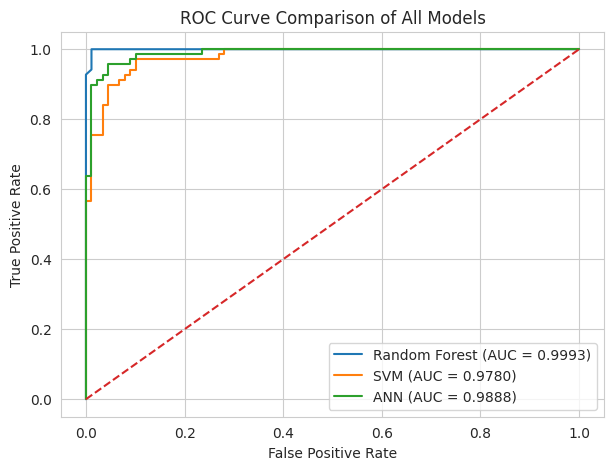

In [ ]:
# ============================================
# CELL 30: Combined ROC curve comparison
# ============================================

plt.figure(figsize=(7, 5))

# Plot ROC curve for Random Forest
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.4f})")

# Plot ROC curve for SVM
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {svm_auc:.4f})")

# Plot ROC curve for ANN
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {ann_auc:.4f})")

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

# Add labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of All Models")
plt.legend()
plt.show()

In [ ]:
# ============================================
# CELL 31: Import hyperparameter tuning tools
# ============================================

from sklearn.model_selection import RandomizedSearchCV

# This is used to ignore warning messages during tuning
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================
# CELL 32: Hyperparameter tuning for Random Forest
# ============================================

# Define parameter values to test for Random Forest
rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Create base Random Forest model
rf = RandomForestClassifier(random_state=42)

# Apply RandomizedSearchCV
# n_iter = number of random combinations to try
# cv = 5-fold cross-validation
# scoring = roc_auc because this is a medical classification task
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train tuning process on unscaled training data
rf_random.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Random Forest Parameters:")
print(rf_random.best_params_)

print("\nBest Random Forest CV ROC-AUC Score:")
print(rf_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}

Best Random Forest CV ROC-AUC Score:
0.9949264423051589


In [ ]:
# ============================================
# CELL 34: Hyperparameter tuning for SVM
# ============================================

# Define parameter values to test for SVM
svm_param_grid = {
    "C": [0.1, 1, 10, 50, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

# Create base SVM model
svm = SVC(probability=True, random_state=42)

# Apply RandomizedSearchCV
svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train tuning process on scaled training data
svm_random.fit(X_train_scaled, y_train)

# Print best parameters and best cross-validation score
print("Best SVM Parameters:")
print(svm_random.best_params_)

print("\nBest SVM CV ROC-AUC Score:")
print(svm_random.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best SVM Parameters:
{'kernel': 'linear', 'gamma': 0.01, 'C': 10}

Best SVM CV ROC-AUC Score:
0.9769078368452391


In [ ]:
# ============================================
# CELL 36: Hyperparameter tuning for ANN
# ============================================

# Define parameter values to test for ANN
ann_param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500, 800, 1000]
}

# Create base ANN model
ann = MLPClassifier(random_state=42)

# Apply RandomizedSearchCV
ann_random = RandomizedSearchCV(
    estimator=ann,
    param_distributions=ann_param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train tuning process on scaled training data
ann_random.fit(X_train_scaled, y_train)

# Print best parameters and best cross-validation score
print("Best ANN Parameters:")
print(ann_random.best_params_)

print("\nBest ANN CV ROC-AUC Score:")
print(ann_random.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best ANN Parameters:
{'solver': 'adam', 'max_iter': 800, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (32,), 'alpha': 0.001, 'activation': 'tanh'}

Best ANN CV ROC-AUC Score:
0.9849649336347301


In [ ]:
# ============================================
# CELL: Evaluate all tuned models
# ============================================

# Get best tuned models
best_rf = rf_random.best_estimator_
best_svm = svm_random.best_estimator_
best_ann = ann_random.best_estimator_

# Make predictions
y_pred_best_rf = best_rf.predict(X_test)
y_pred_best_svm = best_svm.predict(X_test_scaled)
y_pred_best_ann = best_ann.predict(X_test_scaled)

# Print classification reports
print("Tuned Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_best_rf))

print("\n" + "="*60 + "\n")

print("Tuned SVM Classification Report:\n")
print(classification_report(y_test, y_pred_best_svm))

print("\n" + "="*60 + "\n")

print("Tuned ANN Classification Report:\n")
print(classification_report(y_test, y_pred_best_ann))

Tuned Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        89
           1       0.97      1.00      0.99        69

    accuracy                           0.99       158
   macro avg       0.99      0.99      0.99       158
weighted avg       0.99      0.99      0.99       158



Tuned SVM Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.93      0.93        89
           1       0.91      0.90      0.91        69

    accuracy                           0.92       158
   macro avg       0.92      0.92      0.92       158
weighted avg       0.92      0.92      0.92       158



Tuned ANN Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.94      0.97      0.96        69

    accuracy                           0.96       158
   macro avg

Feature Importance from Tuned Random Forest:



,Feature,Importance
7,Troponin,0.716394
6,CK_MB,0.178872
0,Age,0.054558
5,Blood_sugar,0.015183
2,Heart_rate,0.010900
3,Systolic_BP,0.010774
4,Diastolic_BP,0.009319
1,Gender,0.003999


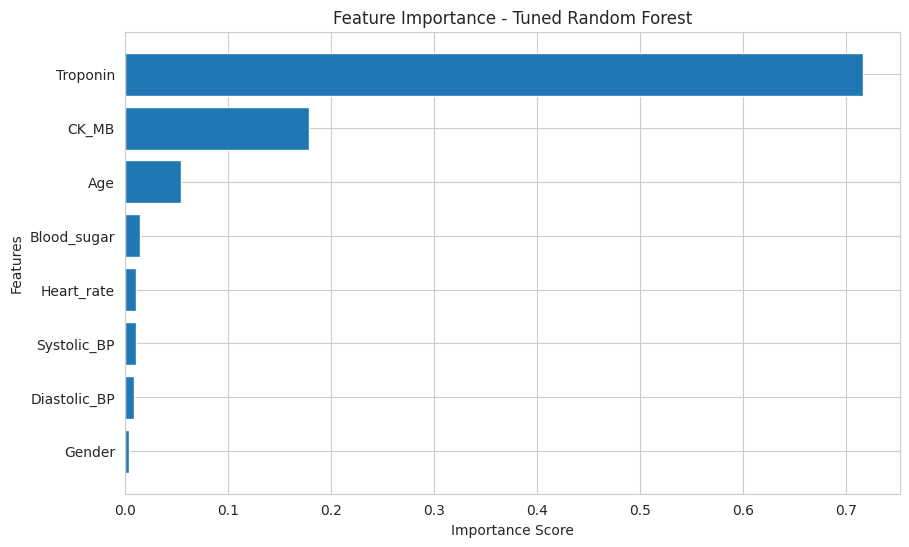

In [ ]:
# ============================================
# CELL: Feature Importance using Random Forest
# ============================================

# Get feature importance values from the tuned Random Forest model
importances = best_rf.feature_importances_

# Create a DataFrame for better display
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Print feature importance table
print("Feature Importance from Tuned Random Forest:\n")
display(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Tuned Random Forest")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()